<a href="https://colab.research.google.com/github/Karsuman4298/Machine_learning/blob/main/Naive_Bayes_VS_Logistic_Reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt

In [110]:
df=pd.read_csv('naive_bayes_10000_dataset.csv')
df

,gender,cgpa,attendance,internship,projects,communication,aptitude_score,coding_score,backlogs,extracurricular,placed
0,Male,7.19,79.99,Yes,1,Medium,84,63,2,No,0
1,Female,7.54,89.87,Yes,3,High,66,75,0,No,1
2,Male,9.17,82.51,No,3,Medium,62,59,0,Yes,0
3,Male,6.96,63.33,No,1,Medium,49,82,1,No,0
4,Male,9.24,67.42,Yes,4,Low,93,84,1,No,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,8.30,73.10,Yes,2,High,48,97,1,No,1
9996,Male,6.26,89.08,Yes,2,Low,52,84,1,Yes,1
9997,Female,5.72,96.93,Yes,1,High,87,61,1,No,1
9998,Female,8.44,85.49,No,4,Low,92,87,2,Yes,0


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           10000 non-null  object 
 1   cgpa             10000 non-null  float64
 2   attendance       10000 non-null  float64
 3   internship       10000 non-null  object 
 4   projects         10000 non-null  int64  
 5   communication    10000 non-null  object 
 6   aptitude_score   10000 non-null  int64  
 7   coding_score     10000 non-null  int64  
 8   backlogs         10000 non-null  int64  
 9   extracurricular  10000 non-null  object 
 10  placed           10000 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 859.5+ KB


In [112]:
df.isnull().sum()

,0
gender,0
cgpa,0
attendance,0
internship,0
projects,0
communication,0
aptitude_score,0
coding_score,0
backlogs,0
extracurricular,0


In [113]:
df.describe()

,cgpa,attendance,projects,aptitude_score,coding_score,backlogs,placed
count,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.634626,80.329206,3.0023,69.499200,69.480700,1.483100,0.431300
std,1.239418,11.530375,1.4194,17.228363,17.256738,1.123317,0.495283
min,5.500000,60.000000,1.0000,40.000000,40.000000,0.000000,0.000000
25%,6.560000,70.430000,2.0000,55.000000,54.000000,0.000000,0.000000
50%,7.610000,80.515000,3.0000,69.000000,70.000000,1.000000,0.000000
75%,8.720000,90.132500,4.0000,84.000000,84.000000,2.000000,1.000000
max,9.800000,100.000000,5.0000,99.000000,99.000000,3.000000,1.000000


In [114]:
target_col=df.columns[-1]
X=df.drop(target_col,axis=1)
y=df[target_col]
le=LabelEncoder()
y=le.fit_transform(y)
X=pd.get_dummies(X)


In [115]:
X

,cgpa,attendance,projects,aptitude_score,coding_score,backlogs,gender_Female,gender_Male,internship_No,internship_Yes,communication_High,communication_Low,communication_Medium,extracurricular_No,extracurricular_Yes
0,7.19,79.99,1,84,63,2,False,True,False,True,False,False,True,True,False
1,7.54,89.87,3,66,75,0,True,False,False,True,True,False,False,True,False
2,9.17,82.51,3,62,59,0,False,True,True,False,False,False,True,False,True
3,6.96,63.33,1,49,82,1,False,True,True,False,False,False,True,True,False
4,9.24,67.42,4,93,84,1,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8.30,73.10,2,48,97,1,True,False,False,True,True,False,False,True,False
9996,6.26,89.08,2,52,84,1,False,True,False,True,False,True,False,False,True
9997,5.72,96.93,1,87,61,1,True,False,False,True,True,False,False,True,False
9998,8.44,85.49,4,92,87,2,True,False,True,False,False,True,False,False,True


In [116]:
y

array([0, 1, 0, ..., 1, 0, 0])

In [117]:
num_cols=X.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1=X[col].quantile(0.25)
    Q3=X[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    mask=(X[col]>=lower)&(X[col]<=upper)
    X=X[mask]
    y=y[mask]


In [118]:
overall_mask = pd.Series(True, index=X.index)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR


    overall_mask = overall_mask & ((X[col] >= lower) & (X[col] <= upper))

X = X[overall_mask]
y = y[overall_mask]

print(f"Shape of X after outlier removal: {X.shape}")
print(f"Shape of y after outlier removal: {y.shape}")

Shape of X after outlier removal: (10000, 15)
Shape of y after outlier removal: (10000,)


In [119]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [120]:
nb=GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [121]:
y_pred_nb=nb.predict(X_test)
nb_acc=accuracy_score(y_test,y_pred_nb)
nb_prec=precision_score(y_test,y_pred_nb,average='weighted')
nb_rec=recall_score(y_test,y_pred_nb,average='weighted')
nb_f1=f1_score(y_test,y_pred_nb,average='weighted')

In [122]:
print("Naive Bayes Accuracy:",nb_acc)
print("Naive Bayes Precision:",nb_prec)
print("Naive Bayes Recall:",nb_rec)
print("Naive Bayes F1 Score:",nb_f1)

Naive Bayes Accuracy: 0.8665
Naive Bayes Precision: 0.8672448502424492
Naive Bayes Recall: 0.8665
Naive Bayes F1 Score: 0.8667356420191213


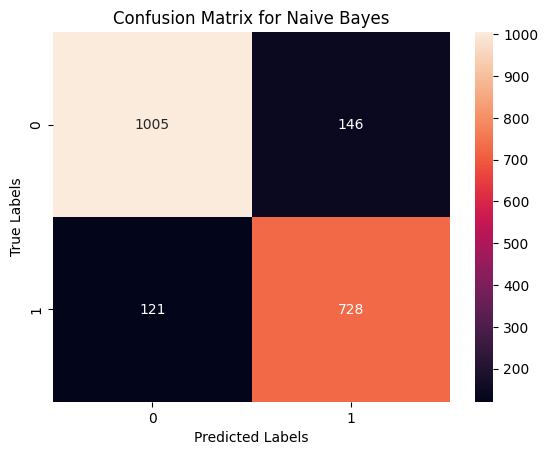

In [123]:
cm_nb=confusion_matrix(y_test,y_pred_nb)
sns.heatmap(cm_nb,annot=True,fmt='d')
plt.title('Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [124]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [125]:
y_pred_lr=lr.predict(X_test)
lr_acc=accuracy_score(y_test,y_pred_lr)
lr_prec=precision_score(y_test,y_pred_lr,average='weighted')
lr_rec=recall_score(y_test,y_pred_lr,average='weighted')
lr_f1=f1_score(y_test,y_pred_lr,average='weighted')
print("Logistic Regression Accuracy:",lr_acc)
print("Logistic Regression Precision:",lr_prec)
print("Logistic Regression Recall:",lr_rec)
print("Logistic Regression F1 Score:",lr_f1)

Logistic Regression Accuracy: 0.907
Logistic Regression Precision: 0.906911465766031
Logistic Regression Recall: 0.907
Logistic Regression F1 Score: 0.9069409206178436


In [126]:
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test,y_pred_lr))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1151
           1       0.89      0.89      0.89       849

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.91      2000



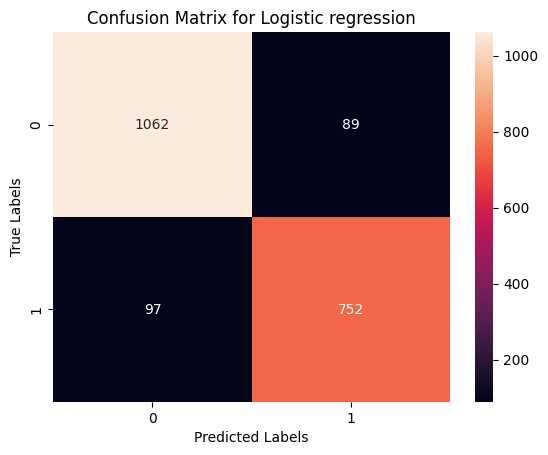

In [127]:
cm_logistic=confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cm_logistic,annot=True,fmt='d')
plt.title('Confusion Matrix for Logistic regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()